# What Docling really produces — sample 2, step by step

Our pipeline gives the model one long string per document, with the formatting
marked in it: `**bold**`, `_italic_`, `++underline++`. We call that the
**annotated text blob**. pdfplumber makes it by reading the PDF's fonts.

Docling is a different tool. So far we have only looked at what it **exports** —
its Markdown (which our extractor uses) and its JSON — and found no bold, italic
or underline in either. This notebook looks at what Docling produces **before**
exporting, on one document, and asks one question per section:

| section | question |
|---|---|
| 1 | What does Docling produce, and at how many levels? |
| 2 | What does the layout model see on the page? |
| 3 | Does Docling read the fonts? (bold, italic, size) |
| 4 | Does Docling see underlines? |
| 5 | Can it find the label that sits inside a paragraph? |
| 6 | Can it find the title? |
| 7 | What survives into the exports, and what does that mean? |

Sample 2 is a template plan with all three kinds of styling. pdfplumber finds
**42 bold, 41 italic and 11 underlined** runs in it.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import collections
import json
import logging
import re
import warnings

os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 150)
SAMPLE = 2
PDF = f'data/input/pdfs/sample{SAMPLE}.pdf'

# The same settings our extractor uses, plus two that tell Docling to KEEP the
# intermediate results it normally throws away after building the document.
opts = PdfPipelineOptions()
opts.do_ocr = True
opts.do_table_structure = True
opts.generate_parsed_pages = True    # keep the raw text cells (fonts, sizes, links)
opts.generate_page_images = True     # keep a picture of each page

converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)})
result = converter.convert(PDF)
doc = result.document
print('converted', PDF, '-', len(result.pages), 'pages')

# pdfplumber's blob for the same document — our reference for what the PDF contains
blob = json.loads(Path(f'data/output/1_extracted/pdfplumber/sample{SAMPLE}.json')
                  .read_text(encoding='utf-8'))[0]['text']
blob_bold  = re.findall(r'\*\* (.+?) \*\*', blob)
blob_ital  = re.findall(r'(?<![\w*+])_ (.+?) _(?![\w])', blob)
blob_under = re.findall(r'\+\+ (.+?) \+\+', blob)
print(f'pdfplumber blob: {len(blob_bold)} bold, {len(blob_ital)} italic, {len(blob_under)} underlined runs')


converted data/input/pdfs/sample2.pdf - 5 pages
pdfplumber blob: 42 bold, 41 italic, 11 underlined runs


## 1. What Docling produces

`convert()` returns one object, a `ConversionResult`. Inside it there are four
levels, from raw to finished:

| level | object | what is in it |
|---|---|---|
| raw text | `page.parsed_page` | every line and word of text, with its **font, size, colour and position**; the page's **hyperlinks** |
| layout | `page.predictions.layout` | boxes the layout model drew round regions, each with a **label and a confidence** |
| page | `page` | the two above, plus a **picture** of the page |
| document | `result.document` | the finished `DoclingDocument`: typed blocks in reading order, each with its page and box |

The Markdown and JSON exports are made from the **document** level only. The
three levels below it are dropped — unless you ask Docling to keep them, which
the two `generate_*` options above do.


In [2]:
page = result.pages[0]
pp = page.parsed_page
print('raw text  :', len(pp.textline_cells), 'lines,', len(pp.word_cells), 'words,',
      len(pp.hyperlinks), 'hyperlinks on page 1')
print('layout    :', len(page.predictions.layout.clusters), 'boxes on page 1')
print('page      :', page.size.width, 'x', page.size.height, 'pt, image', page.image.size)
print('document  :', len(doc.texts), 'text blocks,', len(doc.tables), 'tables,',
      len(doc.groups), 'groups (lists) in the whole document')
print()
print('confidence: Docling is', f'{result.confidence.layout_score:.0%}', 'sure of its layout on this document')


raw text  : 44 lines, 479 words, 3 hyperlinks on page 1
layout    : 10 boxes on page 1
page      : 612.0 x 792.0 pt, image (612, 792)
document  : 36 text blocks, 0 tables, 3 groups (lists) in the whole document

confidence: Docling is 82% sure of its layout on this document


So for page 1 alone Docling has 44 lines and 479 words of raw text, which it
grouped into 10 boxes. The exports never show the 44 lines or the 479 words —
only the 10 boxes' text.


## 2. What the layout model sees

Page 1 as Docling sees it: its own picture of the page, with the boxes it drew
and the label and confidence it gave each one.


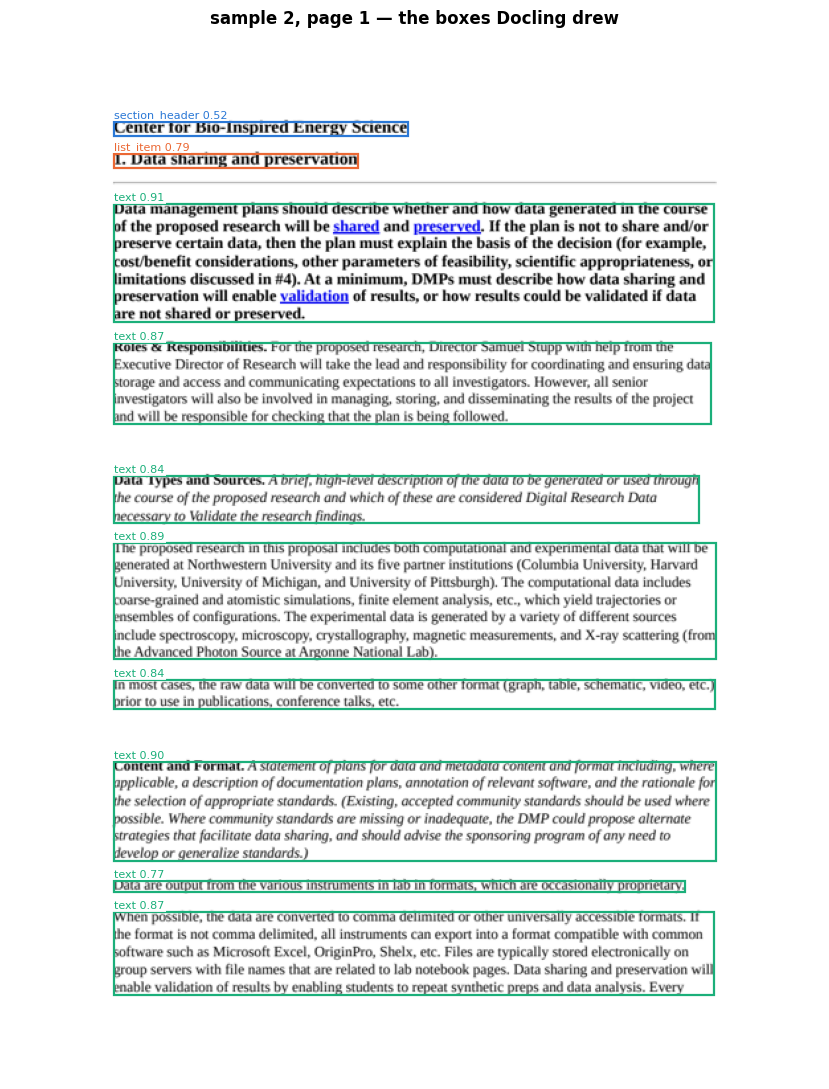

In [3]:
COLOURS = {'section_header': '#2a78d6', 'text': '#1baf7a', 'list_item': '#eb6834'}

fig, ax = plt.subplots(figsize=(8.5, 11))
ax.imshow(page.image)
for c in page.predictions.layout.clusters:
    col = COLOURS.get(str(c.label), '#333')
    ax.add_patch(plt.Rectangle((c.bbox.l, c.bbox.t), c.bbox.r - c.bbox.l, c.bbox.b - c.bbox.t,
                               fill=False, lw=1.6, ec=col))
    ax.text(c.bbox.l, c.bbox.t - 1.5, f'{c.label} {c.confidence:.2f}', fontsize=8, color=col,
            va='bottom', bbox=dict(facecolor='white', alpha=0.9, lw=0, pad=1.2))
ax.set_title('sample 2, page 1 — the boxes Docling drew', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


**What this means.** Docling decides where each block starts and ends — something
the blob does not do (the model has to cut the string itself). It labels the title
a `section_header` at only 0.52 confidence, its least certain call on the page.
And look at the fourth box: `Roles & Responsibilities.` in bold and its answer
in plain text are **one box**. That is the problem the rest of this notebook is
about — in the exports, that box is one paragraph with no trace of the bold.


## 3. Does Docling read the fonts?

Go one level down, to the raw text lines. Each line is a `PdfTextCell` and
carries the font it was set in and its height in points.


In [4]:
rows = [{'line': i, 'text': c.text[:52], 'font': c.font_name.split('+')[-1],
         'size (pt)': round(c.rect.height, 1)}
        for i, c in enumerate(pp.textline_cells[:14])]
display(pd.DataFrame(rows).set_index('line'))


,text,font,size (pt)
line,,,
0,Center for Bio-Inspired Energy Science,Tinos-Bold,10.7
1,1. Data sharing and preservation,Tinos-Bold,10.7
2,Data management plans should describe whether and ho,Tinos-Bold,9.8
3,of the proposed research will be shared and preserve,Tinos-Bold,9.8
4,"preserve certain data, then the plan must explain th",Tinos-Bold,9.8
5,"cost/benefit considerations, other parameters of fea",Tinos-Bold,9.8
6,"limitations discussed in #4). At a minimum, DMPs mus",Tinos-Bold,9.8
7,"preservation will enable validation of results, or h",Tinos-Bold,9.8
8,are not shared or preserved.,Tinos-Bold,9.8


**Yes.** `Tinos-Bold`, `Tinos-Italic`, `Tinos-Regular` — the exact font names
pdfplumber reads. Lines 0–8 are bold (the title and the bold instruction
paragraph). Line 9 is `Roles & Responsibilities.` on its own, in bold; line 10
is the start of its answer, in regular. The split the exports lost is right here.

Counted over the whole document, against the blob:


In [5]:
cells = [c for p in result.pages for c in p.parsed_page.textline_cells]
bold_lines = sum('Bold' in c.font_name for c in cells)
ital_lines = sum('Italic' in c.font_name for c in cells)
display(pd.DataFrame({
    'Docling raw text (lines)':  [bold_lines, ital_lines],
    'pdfplumber blob (runs)':    [len(blob_bold), len(blob_ital)],
    'Docling Markdown / JSON':   [0, 0],
}, index=['bold', 'italic']))


,Docling raw text (lines),pdfplumber blob (runs),Docling Markdown / JSON
bold,42,42,0
italic,41,41,0


**42 and 41 — exactly pdfplumber's numbers.** Docling reads every bold and italic
line of this document. Then, when it builds the document blocks, it keeps the
words and drops the fonts: the JSON has a `formatting` field for bold/italic on
every block, and it is empty on all 36 blocks. The Markdown has no `**` or `*`
at all. The information is read and thrown away, not missing.


## 4. Does Docling see underlines?

In a PDF an underline is not part of the font. It is either a **hyperlink** (the
link annotation draws the line) or a plain **drawn line**. Docling's raw page
reports hyperlinks as rectangles, and drawn shapes as `shapes`. To see what is
under each hyperlink rectangle, take the words whose centre falls inside it.


In [6]:
def words_under(page, rect):
    H = page.size.height
    hb = rect.to_bounding_box().to_top_left_origin(page_height=H)
    out = []
    for w in page.parsed_page.word_cells:
        b = w.rect.to_bounding_box().to_top_left_origin(page_height=H)
        cx, cy = (b.l + b.r) / 2, (b.t + b.b) / 2
        if hb.l - 1 <= cx <= hb.r + 1 and hb.t - 1 <= cy <= hb.b + 1:
            out.append(w.text)
    return ' '.join(out)


links = [words_under(p, h.rect) for p in result.pages for h in p.parsed_page.hyperlinks]
shapes = sum(len(p.parsed_page.shapes) for p in result.pages)
print(f'hyperlinks in the document: {len(links)}   drawn shapes: {shapes}')
print()
print(f"{'text under each hyperlink (Docling)':<52} {'underlined runs (pdfplumber blob)'}")
print('-' * 95)
for a, b in zip(links + [''] * len(blob_under), blob_under + [''] * len(links)):
    if a or b:
        print(f'{a[:50]:<52} {b[:44]}')


hyperlinks in the document: 13   drawn shapes: 0

text under each hyperlink (Docling)                  underlined runs (pdfplumber blob)
-----------------------------------------------------------------------------------------------
shared                                               shared
preserved.                                           preserved.
validation                                           validation
https://arch.library.northwestern.edu/               Principles
Principles                                           description of data management resources
description of data management resources             additional guidance from the sponsporing pro
additional guidance from the sponsporing program.    description of data management resources
description of data management resources             additional guidance
additional guidance                                  from the sponsoring program.
from the sponsoring program.                         Personally
(https://a

**Yes, on this document — because every underline here is a link.** The 11
underlined runs pdfplumber marks are all in Docling's hyperlink list, word for
word (`shared`, `preserved.`, `validation`, `description of data management
resources` …). Docling also lists two raw URLs that pdfplumber skips on purpose.

The limit: a plain drawn underline, with no link behind it, is not in Docling at
any level — `shapes` is 0. Sample 6's five underlined headings are that kind, and
Docling cannot see them. Sample 2 happens to have none.


## 5. Can it find the label inside a paragraph?

The costliest pattern in this corpus is `Label. Answer text…` on one line: the
bold label is a `question.text` in the annotation, the rest is its `answer.text`.
Docling's document has both as one block. But each block knows its box on the
page, and each **word** on the raw page knows its font — so take the words inside
the block's box and read off how many leading ones are bold.


In [7]:
def leading_bold_words(item):
    prov = item.prov[0]
    pg = result.pages[prov.page_no - 1]
    box = prov.bbox.to_top_left_origin(page_height=pg.size.height)
    words = []
    for w in pg.parsed_page.word_cells:
        b = w.rect.to_bounding_box()
        if b.l >= box.l - 1 and b.r <= box.r + 1 and b.t >= box.t - 1 and b.b <= box.b + 1:
            words.append(w)
    lead = []
    for w in words:
        if 'Bold' in w.font_name:
            lead.append(w.text)
        else:
            break
    if lead and len(lead) < len(words):      # a bold prefix, not a wholly bold block
        return ' '.join(lead)
    return ''


rows = []
for it in doc.texts:
    if it.label.value == 'text' and it.prov:
        rows.append({'Docling block (as exported)': it.text[:56],
                     'leading bold words (from raw page)': leading_bold_words(it)})
display(pd.DataFrame(rows).head(12))


,Docling block (as exported),leading bold words (from raw page)
0,Data management plans should describe whether and how da,
1,"Roles & Responsibilities. For the proposed research, Dir",Roles & Responsibilities.
2,"Data Types and Sources. A brief, high-level description",Data Types and Sources.
3,The proposed research in this proposal includes both com,
4,"In most cases, the raw data will be converted to some ot",
5,Content and Format. A statement of plans for data and me,Content and Format.
6,Data are output from the various instruments in lab in f,
7,"When possible, the data are converted to comma delimited",
8,Public talks and outreach activities will generate audio,
9,Data Sharing and Data Preservation. A description of the,Data Sharing and Data Preservation.


**Yes, exactly.** `Roles & Responsibilities.`, `Data Types and Sources.`,
`Content and Format.`, `Data Sharing and Data Preservation.` come back as the
label, and the rest of the block is the answer. This is the split pdfplumber's
blob shows as `** Roles & Responsibilities. ** For the proposed…`, and the split
the Markdown and JSON have already lost. It needs the raw page and the document
together — the block's box from one, the word fonts from the other.


## 6. Can it find the title?

Docling gave the title a `section_header` label, like every other heading — the
JSON has no `title`. But the raw page knows where every line sits.


In [8]:
gold = json.loads(Path(f'data/input/ground_truth_old_version/sample{SAMPLE}_dmp_old.json')
                  .read_text(encoding='utf-8'))['narrative']['template']['title']
lines = [c for c in pp.textline_cells if c.text.strip()]
topmost = min(lines, key=lambda c: c.rect.to_bounding_box().t)
largest = max(lines, key=lambda c: c.rect.height)
print('annotated title      :', gold)
print('topmost line, page 1 :', topmost.text, f'({topmost.rect.height:.1f} pt)')
print('largest line, page 1 :', largest.text, f'({largest.rect.height:.1f} pt)')


annotated title      : Center for Bio-Inspired Energy Science
topmost line, page 1 : Center for Bio-Inspired Energy Science (10.7 pt)
largest line, page 1 : Center for Bio-Inspired Energy Science (10.7 pt)


**Yes.** Both the highest line on the page and the largest line are the title.
(Across all ten documents the *topmost line* rule finds the title 10 times out of
10; the *largest font* rule 7 out of 10. Neither needs the layout model to have
labelled anything.)


## 7. What survives into the exports

Everything above, in one table. "Native" means the raw page plus the document,
kept together.

| information | pdfplumber blob | Docling Markdown | Docling JSON | Docling native |
|---|---|---|---|---|
| where each block starts and ends | no | yes | yes | yes, with a confidence |
| bold | `**` | no | no | **yes** — 42 lines, from font names |
| italic | `_` | no | no | **yes** — 41 lines, from font names |
| underline (hyperlink) | `++` | no | no | **yes** — 11 of 11, as rectangles |
| underline (drawn line) | `++` | no | no | no |
| label inside a paragraph | marker shows it | fused | fused | **recoverable** from word fonts |
| title | first bold line | `##` like any heading | `section_header` | topmost line of page 1 |
| page and position of a block | no | no | yes | yes |
| picture of the page | no | no | no | yes |

### What this means

1. **The earlier conclusion was about the exports, not Docling.** "Docling does not
   report bold, italic or underline" is true of its Markdown and JSON. Its native
   result reads all three on this document — 42 bold, 41 italic, 11 underlines —
   and then drops them on the way out.
2. **The only real gap is drawn underlines**, and sample 2 has none. On documents
   where headings are underlined by hand (sample 6), Docling is blind at every level.
3. **The native result was then put to the test.** Every earlier Docling number
   (0.767 with gemma, 0.709 with rules) was measured on the exports. An extractor
   that builds the annotated blob from the native data instead — fonts for `**`
   and `_`, hyperlink rectangles for `++`, word fonts to split the inline labels,
   blocks in page order — is now what `--extractor docling` does. On this
   document it reproduces pdfplumber's markers exactly, and across the ten it
   scores **0.924 / 0.910** with gemma4:e4b against pdfplumber's 0.946 / 0.951:
   ahead on samples 2 and 5, level on seven, behind only on sample 6 — the drawn
   underlines from point 2. The gap between Docling's exports and its native
   result is worth 16 points; the gap between its native result and pdfplumber
   is one document.
